<a href="https://colab.research.google.com/github/latiyan09/Deep-Learning/blob/main/Diabetes_Data_Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install kaggle

In [1]:
import os
import json
from google.colab import userdata

# Ensure the .kaggle directory exists
!mkdir -p ~/.kaggle

# Read the kaggle.json content from Colab secrets
kaggle_config_data = userdata.get('KAGGLE_CONFIG_DATA')

# Write the content to kaggle.json file
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_config_data)

# Set correct permissions
!chmod 600 /root/.kaggle/kaggle.json

print('Kaggle API key configured successfully!')

Kaggle API key configured successfully!


In [2]:
# Download the dataset files to the current working directory
!kaggle datasets download -d 'uciml/pima-indians-diabetes-database'


print('Dataset downloaded and unzipped successfully!')

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
100% 8.91k/8.91k [00:00<00:00, 15.3MB/s]

Dataset downloaded and unzipped successfully!


In [3]:
!unzip -o pima-indians-diabetes-database.zip

Archive:  pima-indians-diabetes-database.zip
  inflating: diabetes.csv            


In [4]:
import pandas as pd

df = pd.read_csv('diabetes.csv') # Or test.csv, depending on what was unzipped
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.corr()['Outcome']

,Outcome
Pregnancies,0.221898
Glucose,0.466581
BloodPressure,0.065068
SkinThickness,0.074752
Insulin,0.130548
BMI,0.292695
DiabetesPedigreeFunction,0.173844
Age,0.238356
Outcome,1.000000


In [6]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [7]:
x.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [8]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x = sc.fit_transform(x)

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [11]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [12]:
model = Sequential()

In [13]:
model.add(Input(shape=(8,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
history = model.fit(x_train, y_train, batch_size=32,epochs=100,validation_data=(x_test,y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4691 - loss: 0.7852 - val_accuracy: 0.5584 - val_loss: 0.7380
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5814 - loss: 0.7083 - val_accuracy: 0.6364 - val_loss: 0.6723
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6173 - loss: 0.6558 - val_accuracy: 0.6429 - val_loss: 0.6258
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6352 - loss: 0.6196 - val_accuracy: 0.6429 - val_loss: 0.5915
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6515 - loss: 0.5916 - val_accuracy: 0.6623 - val_loss: 0.5662
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6840 - loss: 0.5703 - val_accuracy: 0.6753 - val_loss: 0.5466
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7036 - loss: 0.5526 - val_accuracy: 0.7078 - val_loss: 0.5319
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7199 - loss: 0.5379 - val_accuracy: 0.7468 - 

In [17]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.2 MB/s eta 0:00:00


In [18]:
import keras_tuner as kt

In [19]:
def build_model(hp):
  model = Sequential()

  model.add(Input(shape=(8,)))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))

  optimizer = hp.Choice('optimizer', values = ['adam','sgd','rmsprop','adadelta'])
  model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

  return model

In [20]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5
)

In [21]:
tuner.search(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Trial 4 Complete [00h 00m 04s]
val_accuracy: 0.3961038887500763

Best val_accuracy So Far: 0.7467532753944397
Total elapsed time: 00h 00m 13s


In [22]:
tuner.results_summary()

Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 1 summary
Hyperparameters:
optimizer: rmsprop
Score: 0.7467532753944397

Trial 2 summary
Hyperparameters:
optimizer: adam
Score: 0.7337662577629089

Trial 0 summary
Hyperparameters:
optimizer: sgd
Score: 0.6948052048683167

Trial 3 summary
Hyperparameters:
optimizer: adadelta
Score: 0.3961038887500763


In [23]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

In [24]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
model.fit(x_train, y_train, batch_size=32,epochs=100,initial_epoch=10,validation_data=(x_test,y_test))

Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7720 - loss: 0.4774 - val_accuracy: 0.7532 - val_loss: 0.5225
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7785 - loss: 0.4703 - val_accuracy: 0.7532 - val_loss: 0.5201
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7785 - loss: 0.4666 - val_accuracy: 0.7468 - val_loss: 0.5194
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7818 - loss: 0.4628 - val_accuracy: 0.7468 - val_loss: 0.5199
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7834 - loss: 0.4595 - val_accuracy: 0.7468 - val_loss: 0.5189
Epoch 16/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7866 - loss: 0.4567 - val_accuracy: 0.7468 - val_loss: 0.5203
Epoch 17/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7866 - loss: 0.4544 - val_accuracy: 0.7532 - val_loss: 0.5189
Epoch 18/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7818 - loss: 0.4526 - val_accuracy: 

In [41]:
def build_model(hp):

  model = Sequential()

  units = hp.Int('units', min_value=8, max_value=128, step=8)

  model.add(Input(shape=(8,)))
  model.add(Dense(units, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))

  model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

  return model

In [42]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='my_dir',
    project_name='my_project'
)

In [43]:
tuner.search(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Trial 5 Complete [00h 00m 03s]
val_accuracy: 0.7337662577629089

Best val_accuracy So Far: 0.7662337422370911
Total elapsed time: 00h 00m 17s


In [44]:
tuner.results_summary()

Results summary
Results in my_dir/my_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 2 summary
Hyperparameters:
units: 56
Score: 0.7662337422370911

Trial 0 summary
Hyperparameters:
units: 120
Score: 0.7532467246055603

Trial 1 summary
Hyperparameters:
units: 72
Score: 0.7532467246055603

Trial 4 summary
Hyperparameters:
units: 40
Score: 0.7337662577629089

Trial 3 summary
Hyperparameters:
units: 24
Score: 0.7142857313156128


In [45]:
tuner.get_best_hyperparameters()[0].values

{'units': 56}

In [46]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 56)             │           504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 561 (2.19 KB)

 Trainable params: 561 (2.19 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.fit(x_train, y_train, batch_size=32,epochs=100,initial_epoch=10,validation_data=(x_test,y_test))

Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7818 - loss: 0.4780 - val_accuracy: 0.7597 - val_loss: 0.4863
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7883 - loss: 0.4653 - val_accuracy: 0.7532 - val_loss: 0.4850
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7932 - loss: 0.4577 - val_accuracy: 0.7468 - val_loss: 0.4863
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7915 - loss: 0.4521 - val_accuracy: 0.7468 - val_loss: 0.4885
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7948 - loss: 0.4488 - val_accuracy: 0.7468 - val_loss: 0.4860
Epoch 16/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7915 - loss: 0.4454 - val_accuracy: 0.7468 - val_loss: 0.4860
Epoch 17/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7899 - loss: 0.4422 - val_accuracy: 0.7468 - val_loss: 0.4867
Epoch 18/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7866 - loss: 0.4406 - val_accurac

In [61]:
def build_model(hp):

  model = Sequential()

  units = hp.Int('units', min_value=8, max_value=128, step=8)

  model.add(Input(shape=(8,)))

  for i in range(hp.Int('num_layers', min_value=1, max_value=10)):
    model.add(Dense(units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

  model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

  return model


In [62]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='my_dir',
    project_name='my_project_3'
)

In [63]:
tuner.search(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Trial 5 Complete [00h 00m 06s]
val_accuracy: 0.6363636255264282

Best val_accuracy So Far: 0.6363636255264282
Total elapsed time: 00h 00m 33s


In [64]:
tuner.results_summary()

Results summary
Results in my_dir/my_project_3
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0 summary
Hyperparameters:
units: 104
num_layers: 10
Score: 0.6363636255264282

Trial 1 summary
Hyperparameters:
units: 48
num_layers: 8
Score: 0.6363636255264282

Trial 2 summary
Hyperparameters:
units: 64
num_layers: 6
Score: 0.6363636255264282

Trial 3 summary
Hyperparameters:
units: 16
num_layers: 5
Score: 0.6363636255264282

Trial 4 summary
Hyperparameters:
units: 16
num_layers: 4
Score: 0.6363636255264282


In [65]:
tuner.get_best_hyperparameters()[0].values

{'units': 104, 'num_layers': 10}

In [74]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

def build_model(hp):
  model = Sequential()

  model.add(Input(shape=(8,)))

  # Tune the number of hidden layers
  for i in range(hp.Int('num_hidden_layers', min_value=1, max_value=5)):
    # Tune the number of units in each Dense layer
    # Add L2 regularization to dense layers
    l2_rate = hp.Float(f'l2_rate_layer_{i}', min_value=1e-5, max_value=1e-2, sampling='LOG', default=1e-4)
    model.add(Dense(units=hp.Int(f'units_layer_{i}', min_value=8, max_value=128, step=8),
                    activation='relu',
                    kernel_regularizer=regularizers.l2(l2_rate)))
    # Tune the dropout rate for each layer
    model.add(Dropout(hp.Float(f'dropout_layer_{i}', min_value=0.0, max_value=0.5, step=0.1)))

  model.add(Dense(1, activation='sigmoid'))

  model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

  return model

In [75]:
import tensorflow as tf

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='my_dir_new_model',
    project_name='tuned_deep_model_1'
)

In [76]:
tuner.search(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Trial 5 Complete [00h 00m 04s]
val_accuracy: 0.6363636255264282

Best val_accuracy So Far: 0.7467532753944397
Total elapsed time: 00h 00m 25s


In [77]:
tuner.results_summary()

Results summary
Results in my_dir_new_model/tuned_deep_model_1
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 3 summary
Hyperparameters:
num_hidden_layers: 2
l2_rate_layer_0: 0.00012366265065771382
units_layer_0: 80
dropout_layer_0: 0.1
l2_rate_layer_1: 0.007863429392778105
units_layer_1: 8
dropout_layer_1: 0.0
l2_rate_layer_2: 3.529985484659928e-05
units_layer_2: 56
dropout_layer_2: 0.30000000000000004
l2_rate_layer_3: 3.648737509558384e-05
units_layer_3: 16
dropout_layer_3: 0.2
l2_rate_layer_4: 0.0028928514683838856
units_layer_4: 88
dropout_layer_4: 0.2
Score: 0.7467532753944397

Trial 0 summary
Hyperparameters:
num_hidden_layers: 1
l2_rate_layer_0: 0.0019007804493306605
units_layer_0: 48
dropout_layer_0: 0.4
Score: 0.7402597665786743

Trial 2 summary
Hyperparameters:
num_hidden_layers: 4
l2_rate_layer_0: 0.001495022851387891
units_layer_0: 8
dropout_layer_0: 0.2
l2_rate_layer_1: 0.00029883401391728724
units_layer_1: 72
dropout_layer_1: 0.4
l2_rate_lay

In [78]:
tuner.get_best_hyperparameters()[0].values

{'num_hidden_layers': 2,
 'l2_rate_layer_0': 0.00012366265065771382,
 'units_layer_0': 80,
 'dropout_layer_0': 0.1,
 'l2_rate_layer_1': 0.007863429392778105,
 'units_layer_1': 8,
 'dropout_layer_1': 0.0,
 'l2_rate_layer_2': 3.529985484659928e-05,
 'units_layer_2': 56,
 'dropout_layer_2': 0.30000000000000004,
 'l2_rate_layer_3': 3.648737509558384e-05,
 'units_layer_3': 16,
 'dropout_layer_3': 0.2,
 'l2_rate_layer_4': 0.0028928514683838856,
 'units_layer_4': 88,
 'dropout_layer_4': 0.2}

Let's retrieve the best model found by the tuner and display its summary and then train it for more epochs.

In [79]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 80)             │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377 (5.38 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
history = best_model.fit(x_train, y_train, batch_size=32, epochs=100, validation_data=(x_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7492 - loss: 0.6293 - val_accuracy: 0.7403 - val_loss: 0.5944
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7704 - loss: 0.5876 - val_accuracy: 0.7273 - val_loss: 0.5796
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7834 - loss: 0.5657 - val_accuracy: 0.7532 - val_loss: 0.5682
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7932 - loss: 0.5432 - val_accuracy: 0.7597 - val_loss: 0.5613
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7769 - loss: 0.5391 - val_accuracy: 0.7532 - val_loss: 0.5548
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7834 - loss: 0.5271 - val_accuracy: 0.7532 - val_loss: 0.5465
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7866 - loss: 0.5243 - val_accuracy: 0.7532 - val_loss: 0.5464
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7980 - loss: 0.5149 - val_accuracy: 0.7532 - 

Text(0.5, 1.0, 'Model Accuracy')

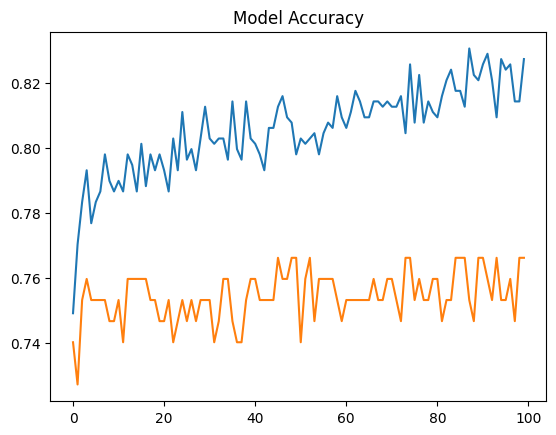

In [82]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
